<a href="https://colab.research.google.com/github/grossil26/more-than-words/blob/main/Definitive_Project_DFB_1DCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MORE THAN WORDS: SPEAKER RECOGNITION DATASET

Speaker recognition stands as a cornerstone technology in modern biometrics and digital forensics, facilitating the automated determination of identity through the analysis of unique vocal characteristics. This project, titled "More Than Words" , explores the implementation of a text-independent speaker recognition system capable of operating in two distinct modes: speaker identification and speaker verification.
- Identification aims to classify a voice sample into one of several known identities (a 1:N problem), typically utilized in closed environments where the user population is fixed.
- Verification determines whether two voice samples belong to the same individual (a 1:1 comparison), a critical function for forensic applications where the subject may be unknown to the system or absent from the training database.



To achieve robust performance across these scenarios, the proposed pipeline utilizes **Mel-Frequency Cepstral Coefficients** (MFCCs) to extract the unique spectral envelope of the human voice, effectively isolating speaker-specific traits from raw audio. These features serve as the input for a Convolutional Neural Network (CNN), a deep learning architecture selected for its ability to learn hierarchical patterns within the frequency-time domain. The project is structured to first train a classifier in a closed-set scenario to establish a baseline of feature learning. Subsequently, the system is evaluated in an open-set context, where the model must generate discriminative embeddings to verify the identity of speakers it has never encountered during training, thereby simulating a realistic forensic deployment.

## Dataset Overview and Description

The experimental analysis relies on the "Speaker Recognition Audio Dataset" sourced from Kaggle , which is specifically designated for the "More Than Words" speaker recognition project. This corpus is structured into a directory of 50 distinct folders, where each folder represents a unique speaker identity and contains a collection of short speech recordings in WAV format. This organization provides a labeled set of audio samples, facilitating the supervised training of machine learning models by associating specific acoustic features (such as pitch, tone, and cadence) with ground-truth identities. The dataset includes recordings from prominent public figures, ensuring a diverse range of vocal characteristics and speaking styles, which is critical for testing the generalization capabilities of a biometric system.

This dataset is particularly well-suited for simulating real-world forensic scenarios due to its support for both closed-set and open-set protocols. For closed-set identification, the sufficiently large number of samples per speaker allows the model to capture intra-class variability during the training phase. Conversely, the dataset's modular structure enables the partitioning of speakers into disjoint sets, reserving a subset of identities strictly for testing; this creates a "zero-shot" learning environment necessary for open-set verification, where the system must evaluate speakers it has never encountered. Inherent challenges in the dataset, such as varying clip durations, potential background noise, and limited utterance lengths, further serve to stress-test the robustness of the preprocessing pipeline and the feature extraction mechanisms.

### 1 - Library Installation and Dataset Download
This initial step sets up the working environment. We install opendatasets, a library that facilitates downloading datasets directly from Kaggle using an API key.

From a forensic perspective, ensuring the integrity and origin of the dataset is the first step in the Chain of Custody. By downloading directly from the source, we ensure we are working on the correct, unaltered raw data.

In [ ]:
import os
import shutil

#install the library to download from Kaggle
print("Installing opendatasets library...")
!pip install opendatasets --quiet

import opendatasets as od

#download the dataset
dataset_url = 'https://www.kaggle.com/datasets/vjcalling/speaker-recognition-audio-dataset'
print("Downloading dataset... (Please enter your Kaggle credentials when prompted)")
od.download(dataset_url)

Installing opendatasets library...
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sus
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/vjcalling/speaker-recognition-audio-dataset


100%|██████████| 3.64G/3.64G [00:51<00:00, 75.6MB/s]


### 2 - Dataset Path Verification
Here we define the file system paths. This is a robust coding practice to ensure the data is located where we expect it before proceeding. In forensic software engineering, hardcoding paths without verification can lead to runtime errors that invalidate the process.

We specifically look for the 50_speakers_audio_data directory, which contains the raw WAV files organized by speaker.

In [ ]:
#locate the audio root folder
base_dir = './speaker-recognition-audio-dataset' #folder
AUDIO_ROOT = None

expected_sub_dir = os.path.join(base_dir, '50_speakers_audio_data') #speaker folders

#attribute to AUDIO_ROOT  the path expected_sub_dir
if os.path.isdir(expected_sub_dir):
    AUDIO_ROOT = expected_sub_dir

### 3 – Importing Scientific Libraries
We import the core libraries required for Digital Signal Processing (DSP) and Machine Learning (ML).

Librosa: The standard library for audio analysis. It handles loading audio and extracting features (MFCCs).

Numpy: Used for matrix operations, as audio signals are essentially numerical arrays.

Sklearn (Scikit-learn): Provides utilities for data splitting and Label Encoding, which are essential for preparing data for the neural network.

In [ ]:
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm #progress bar

### 4 – Signal Processing Parameters
We define the global hyperparameters for the signal processing pipeline.

SAMPLE_RATE (16kHz): We resample all audio to 16,000 Hz. Human speech generally falls within 85 Hz to 255 Hz (fundamental frequency), but harmonics extend higher. According to the Nyquist-Shannon theorem, a 16kHz sample rate captures frequencies up to 8kHz, which is sufficient for high-quality voice recognition without unnecessary computational load.

DURATION (1 second): Neural networks require fixed-size input vectors. We standardize every audio clip to exactly 1 second.

N_MFCC (40): The number of Mel-Frequency Cepstral Coefficients to extract. These coefficients represent the short-term power spectrum of a sound, simulating the human ear's response (Mel scale). 40 is a standard choice for speaker recognition to capture the "timbre" of the voice.

In [ ]:
SAMPLE_RATE = 16000
DURATION = 1
N_MFCC = 40

### 5 – Feature Extraction Function (MFCC)
This function is the core of the preprocessing pipeline.

1. Loading: We load the audio. If the file is longer than 1 second, librosa automatically truncates it.
2. Padding: If the file is shorter than 1 second, we pad it with zeros (silence). This ensures valid matrix dimensions for the CNN.MFCC;
3. Extraction: We convert the time-domain signal (amplitude over time) into the frequency domain (MFCCs). MFCCs are the standard feature for speech because they de-correlate the source (vocal cords) from the filter (vocal tract shape), effectively isolating the speaker's unique biometric characteristics.
4. Normalization: We subtract the mean and divide by the standard deviation. This creates a distribution with $\mu=0$ and $\sigma=1$. Normalization is critical for Neural Networks to prevent vanishing/exploding gradients and ensure faster convergence.
5. Transposition: We return the matrix as (Time, Features) because a 1D Convolutional Neural Network (Conv1D) expects the time steps to be the first dimension.

In [ ]:
def extract_mfcc(file_path):
  #1. load
  audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)

  #2. padding if audio is too short (less than 1 sec)
  if len(audio) < SAMPLE_RATE * DURATION:
    padding = (SAMPLE_RATE * DURATION) - len(audio)
    audio = np.pad(audio, (0, padding), 'constant')

  #3. extraction: calculate MFCC
  mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)

  #4. normalization (Standardization)
  mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)

  #5. transposition: shape (Time, Features) for the CNN
  return mfcc.T

### 6 – Split Speakers (Training, Validation, Testing)
We divide the speakers (identities) into three distinct groups. This ensures a rigorous evaluation protocol:

1.  Training Speakers (70%): Used to train the Neural Network (Closed-Set Identification).
2.  Validation Speakers (16%): Used strictly to tune the biometric threshold. Since we don't know the optimal similarity score cutoff, we use this set to calculate the Equal Error Rate (EER) and find the best threshold.
3.  Testing Speakers (14%): Used for the final Open-Set evaluation. These speakers are completely unseen by the model and were not used to set the threshold.

This "Three-Set" approach prevents information leakage and simulates a real-world forensic scenario where the system must handle entirely new subjects.

In [ ]:
all_speakers = [d for d in os.listdir(AUDIO_ROOT) if os.path.isdir(os.path.join(AUDIO_ROOT, d))] #get all subdirectories (speaker names)
np.random.shuffle(all_speakers) #shuffle to ensure random split

#split Speakers: 70% Train, 16% Val, 14% Test
n_speakers = len(all_speakers)
n_train = int(n_speakers * 0.7)
n_val = int(n_speakers * 0.16)

train_speakers_list = all_speakers[:n_train] #for Training the CNN
val_speakers_list = all_speakers[n_train:n_train+n_val] #for Finding Threshold
test_speakers_list = all_speakers[n_train+n_val:] #for Final Open-Set Test

print(f"Total Speakers: {len(all_speakers)}")
print(f"Training (Closed-Set): {len(train_speakers_list)} speakers")
print(f"Validation (Threshold Tuning): {len(val_speakers_list)} speakers")
print(f"Testing (Open-Set Eval): {len(test_speakers_list)} speakers")

Total Speakers: 50
Training (Closed-Set): 35 speakers
Validation (Threshold Tuning): 8 speakers
Testing (Open-Set Eval): 7 speakers


### 7 – Data Loader Function
This helper function iterates through the folders of the selected speakers and processes every WAV file. A key detail here is the dimension check. MFCC extraction on a 1-second clip results in a specific number of time frames (typically 32 frames for standard hop lengths). librosa.util.fix_length forces the time axis to exactly 32. This guarantees that every single input matrix $X$ has the shape (32, 40), which is mandatory for the CNN input layer.
Furthermore, Data Augmentation is done: adding Gaussian Noise (slight random variations) helps the model reach stability.

In [ ]:
def load_data(speaker_list):
    X = []
    y = []

    for speaker in tqdm(speaker_list, desc="Loading Audio"):
      speaker_path = os.path.join(AUDIO_ROOT, speaker)
      if not os.path.isdir(speaker_path): continue

      for filename in os.listdir(speaker_path):
        file_path = os.path.join(speaker_path, filename)
        mfcc = extract_mfcc(file_path)

        #validity Check and Shape Enforcement
        if mfcc is not None:
          target_len = 32 #fixed lenght (32, 40)
          if mfcc.shape[0] != target_len:
            mfcc = librosa.util.fix_length(mfcc, size=target_len, axis=0)

          X.append(mfcc)
          y.append(speaker)

          # DATA AUGMENTATION
          noise = np.random.normal(0, 0.01, mfcc.shape)
          augmented_mfcc = mfcc + noise
          X.append(augmented_mfcc)
          y.append(speaker)

    return np.array(X), np.array(y)

### 8 – Loading Training Data
We execute the loader for the Training List (Closed-Set). This dataset will be used to teach the Neural Network how to distinguish between different voices.

In [ ]:
X_train_raw, y_train_raw = load_data(train_speakers_list)

Loading Audio:   0%|          | 0/35 [00:00<?, ?it/s]

### 9 – Label Encoding
Neural Networks cannot understand strings like "Nelson_Mandela" or "Margaret_Thatcher". They require numerical targets. Label Encoding converts the list of names into integers (0, 1, 2, ... N). For example: Speaker A $\rightarrow$ 0 Speaker B $\rightarrow$ 1. This allows us to use sparse_categorical_crossentropy as our loss function, which efficiently handles integer targets for multi-class classification.

In [ ]:
#encode labels (Name -> ID)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_raw)

### 10 – Closed-Set Data Splitting
For the Closed-Set task (identifying the 35 specific training speakers), we also require a three-way split of the audio files.

1.  Training Set: used to update the weights of the CNN (backpropagation).
2.  Validation Set: used to monitor loss and accuracy during training (to prevent overfitting).
3.  Testing Set: a held-out subset of audio files that is **never** used during training. We will use this set at the very end to generate the Confusion Matrix.

This ensures that our reported accuracy for the Closed-Set task is unbiased and reflects the model's performance on new recordings of known speakers.

In [ ]:
#load data only for train_speakers_list
X_full, y_full = load_data(train_speakers_list)
y_full_enc = le.fit_transform(y_full)

#split out the Test set (14% of train data)
X_train_val, X_test_closed, y_train_val, y_test_closed = train_test_split(X_full, y_full_enc, test_size=0.14, random_state=42, stratify=y_full_enc)


#split remaining into Train (70%) and Valid (16%)
#we need 16% of the TOTAL data, but we are splitting the remaining 86% --> 0.16 / 0.86 = ~0.186
X_train, X_val_closed, y_train, y_val_closed = train_test_split(X_train_val, y_train_val, test_size=0.186, random_state=42, stratify=y_train_val)

print(f"Closed-Set Train: {X_train.shape}")
print(f"Closed-Set Val:   {X_val_closed.shape}")
print(f"Closed-Set Test:  {X_test_closed.shape}")

Loading Audio:   0%|          | 0/35 [00:00<?, ?it/s]

Closed-Set Train: (2530, 32, 40)
Closed-Set Val:   (579, 32, 40)
Closed-Set Test:  (507, 32, 40)


### 11 – Deep Learning Imports
We import TensorFlow and Keras. Keras is chosen because it is a high-level API that allows for rapid prototyping of deep learning models. It provides the Conv1D and Dense layers we need to build our architecture. Matplot is used to plot the results in a graph. StratifiedKFold is used instead for the following K-fold cross validation.

In [ ]:
!pip install tensorflow --quiet
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

### 12 – CNN Architecture Definition
We design a 1D Convolutional Neural Network (CNN).

Input Shape (32, 40): 32 time steps, 40 MFCC features.

- Conv1D: we use 1D convolution because audio is temporal. The kernel slides along the time axis, detecting patterns in how the frequencies change over time.

- MaxPooling1D: reduces the dimensionality (down-sampling) while retaining the most important features. It makes the model translation-invariant (small time shifts don't change the result).

- Dropout: randomly disables neurons during training (e.g., 14%). This forces the network to learn redundant representations, preventing it from memorizing specific training samples (overfitting).

- Dense (Softmax): the final layer has one neuron per speaker. Softmax converts the output into a probability distribution (e.g., "90% probability this is Speaker A").

Also L2 regularization is added to prevent overfitting on our small dataset and Optimizers to minimize the loss function by adjusting network weights during training (Optimizer (Adam): an adaptive learning rate optimization algorithm. It is the industry standard because it converges faster than standard Stochastic Gradient Descent (SGD);Loss Function (Sparse Categorical Crossentropy): measures the distance between the predicted probability distribution and the true label (integer); Metric (Accuracy): simply counts the percentage of correct predictions).

In [ ]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = len(train_speakers_list)

def create_robust_model():
    model = models.Sequential([
        layers.Conv1D(64, 3, activation='relu', input_shape=input_shape,
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),

        layers.Conv1D(128, 3, activation='relu',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])

    opt = optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

### 13 – Prepare data for K-Fold
We merge training and validation sets to allow K-Fold rotation and define 5 folds.

In [ ]:
X_kfold = np.concatenate((X_train, X_val_closed), axis=0)
y_kfold = np.concatenate((y_train, y_val_closed), axis=0)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 14 – Model Training
We initiate the training loop using `X_train` and `y_train`. Crucially, we validate performance after every epoch using `X_val_closed`.

We **do not** use `X_test_closed` here. That set remains "locked" until the final evaluation (Cell 18). This strict separation ensures that our training decisions (like when to stop training) are not biased by the final test data.

During the K-Fold Training Execution we used Early Stopping to prevent overfitting (patience=10 means: "stop if val_loss doesn't improve for 10 consecutive epochs").

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

fold_no = 1
all_histories = []

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for train_index, val_index in skf.split(X_kfold, y_kfold):
    print(f'--- Training Fold {fold_no} ---')

    X_train_f, X_val_f = X_kfold[train_index], X_kfold[val_index]
    y_train_f, y_val_f = y_kfold[train_index], y_kfold[val_index]

    model_fold = create_robust_model()

    history = model_fold.fit(
        X_train_f, y_train_f,
        epochs=100,             # 100 Epochs, EarlyStopping will stop it earlier if needed
        batch_size=128,          # High batch size helps with 50 different classes
        shuffle=True,
        validation_data=(X_val_f, y_val_f),
        callbacks=[early_stop],
        verbose=1
    )

    all_histories.append(history.history)
    fold_no += 1

model = model_fold

--- Training Fold 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 403ms/step - accuracy: 0.0533 - loss: 3.9822 - val_accuracy: 0.0547 - val_loss: 3.7577
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0690 - loss: 3.6949 - val_accuracy: 0.1077 - val_loss: 3.4619
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0994 - loss: 3.4491 - val_accuracy: 0.2540 - val_loss: 3.1813
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1601 - loss: 3.1897 - val_accuracy: 0.3248 - val_loss: 2.8263
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2226 - loss: 2.8999 - val_accuracy: 0.4373 - val_loss: 2.4460
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3312 - loss: 2.5422 - val_accuracy: 0.4904 - val_loss: 2.1391
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3810 - loss: 2.3023 - val_accuracy: 0.5595 - val_loss: 1.8788
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4384 - loss: 2.0577 - val_accuracy: 0.6206 

### 15 – Training Visualization
Visualizing the learning curves is essential for forensic reporting.

If Training Accuracy is high but Validation Accuracy is low, the model is overfitting (memorizing).

If both increase together, the model is learning generalized features.

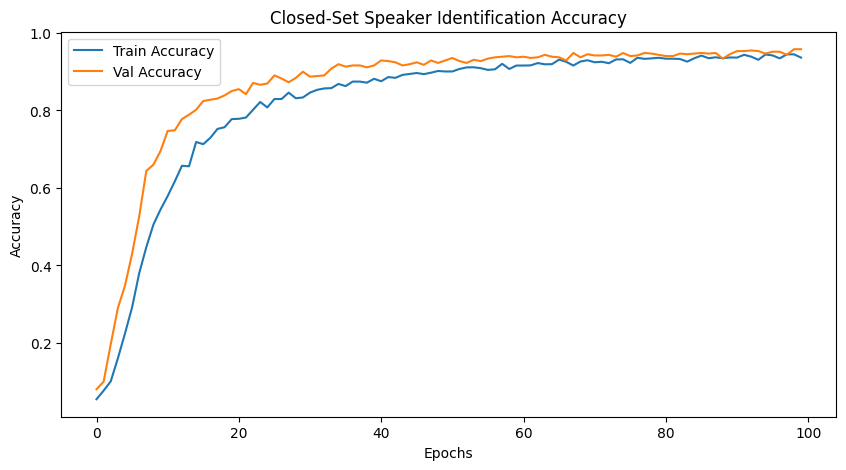

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Closed-Set Speaker Identification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 16 – Open-Set Strategy: Feature Extractor
For the Open-Set task (verifying unseen people), we cannot use the final classification layer (Softmax), because it is hardcoded to the specific training speakers.

Instead, we slice the model to remove the last layer. We use the model as a Feature Extractor. The output will now be the dense vector (embedding) from the layer before the classification. Ideally, this vector contains a mathematical summary of the speaker's voice characteristics.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import itertools

feature_extractor = models.Sequential(model.layers[:-1]) #we create a new model using all layers except the last classification layer

### 17 – Open-Set Verification & Threshold Tuning
This section implements the Open-Set Biometric Verification pipeline in two distinct phases.

1. Validation (Threshold Tuning)

We generate embeddings for the Validation Speakers. Using these, we compute the Receiver Operating Characteristic (ROC) curve and calculate the Equal Error Rate (EER). The EER represents the point where the False Acceptance Rate (FAR) equals the False Rejection Rate (FRR). The threshold corresponding to this point is selected as our Optimal Threshold.

2. Testing (Final Evaluation)

We apply the *learned* threshold from Phase 1 to the Testing Speakers. This provides a fair assessment of how well the system generalizes to completely new people without manually "guessing" the cutoff.

Before doing that, the Helper Function  "get_verification_data" processes the raw data.
Input: It takes a list of speakers and the trained model.
Embeddings: It converts the audio files into mathematical vectors (lists of numbers) called "embeddings".
Pairing: It creates pairs of recordings (e.g., Recording A vs. Recording B).
Note: It limits this to 10,000 pairs to prevent the computer from crashing.
Scoring: It compares each pair using Cosine Similarity (High Score: The recordings sound very similar (likely the same person); Low Score: The recordings sound different (likely different people)).
Truth Labels: It creates an answer key: 1 if the pair is actually the same person, 0 if they are different.

In [ ]:
from sklearn.metrics import accuracy_score

#helper function: get scores and labels
def get_verification_data(speaker_list, model, max_pairs=10000):
    """
    Generates pairs and calculates cosine similarity scores.
    Returns: true_labels (1 for same, 0 for diff), similarity_scores
    """
    if not speaker_list:
        return [], []

    #load Data & Embeddings
    print(f"Processing {len(speaker_list)} speakers...")
    X_data, y_data = load_data(speaker_list)
    if len(X_data) == 0: return [], []

    embeddings = model.predict(X_data, verbose=0)

    #generate Pairs
    indices = range(len(X_data))
    all_pairs = list(itertools.combinations(indices, 2))

    #randomly sample if too many pairs (to prevent crashing)
    if len(all_pairs) > max_pairs:
        import random
        random.shuffle(all_pairs)
        all_pairs = all_pairs[:max_pairs]

    #calculate Scores
    labels = []
    scores = []

    print(f"Computing similarity for {len(all_pairs)} pairs...")

    for idx1, idx2 in tqdm(all_pairs, desc="Calculating Scores"):
        #truth: 1 if same speaker, 0 if different
        labels.append(1 if y_data[idx1] == y_data[idx2] else 0)

        #score: Cosine Similarity
        vec1 = embeddings[idx1].reshape(1, -1)
        vec2 = embeddings[idx2].reshape(1, -1)
        sim = cosine_similarity(vec1, vec2)[0][0]
        scores.append(sim)

    return np.array(labels), np.array(scores)

#A. validation phase (finding Threshold)
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

val_labels, val_scores = get_verification_data(val_speakers_list, feature_extractor)

# 1. calculate False Positive Rate (fpr) and True Positive Rate (tpr)
fpr, tpr, thresholds = roc_curve(val_labels, val_scores, pos_label=1)

# 2. calculate Equal Error Rate (EER is where FPR == 1 - TPR (or FPR == FNR)
eer = brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

# 3. find the Threshold that corresponds to this EER
best_threshold = interp1d(fpr, thresholds)(eer)

print(f"Balanced EER found: {eer:.2%}")
print(f"Optimal Threshold (Intersection): {best_threshold:.4f}")

#B. testing phase (final evaluation)
test_labels, test_scores = get_verification_data(test_speakers_list, feature_extractor)

#apply the learned threshold
test_preds = (test_scores > best_threshold).astype(int)
final_accuracy = accuracy_score(test_labels, test_preds)

print("\n" + "="*40)
print(f"FINAL BIOMETRIC VERIFICATION RESULTS")
print("="*40)
print(f"Threshold Used: {best_threshold:.2f}")
print(f"Pairs Tested: {len(test_labels)}")
print(f"FINAL ACCURACY: {final_accuracy*100:.2f}%")
print("="*40)

Processing 8 speakers...


Loading Audio:   0%|          | 0/8 [00:00<?, ?it/s]

Computing similarity for 10000 pairs...


Calculating Scores:   0%|          | 0/10000 [00:00<?, ?it/s]

Balanced EER found: 20.72%
Optimal Threshold (Intersection): 0.6420
Processing 7 speakers...


Loading Audio:   0%|          | 0/7 [00:00<?, ?it/s]

Computing similarity for 10000 pairs...


Calculating Scores:   0%|          | 0/10000 [00:00<?, ?it/s]


FINAL BIOMETRIC VERIFICATION RESULTS
Threshold Used: 0.64
Pairs Tested: 10000
FINAL ACCURACY: 92.09%


### 18 – Confusion Matrix (Closed-Set Analysis)
To evaluate the Closed-Set classifier, we generate predictions on the Test Set (`X_test_closed`).

Unlike the Validation set (which influenced the training process), this Test set provides an independent measure of the model's ability to distinguish between the known speakers. The Confusion Matrix helps us identify specific voice pairs that are acoustically similar and prone to misclassification.

Generating Confusion Matrix for Closed-Set


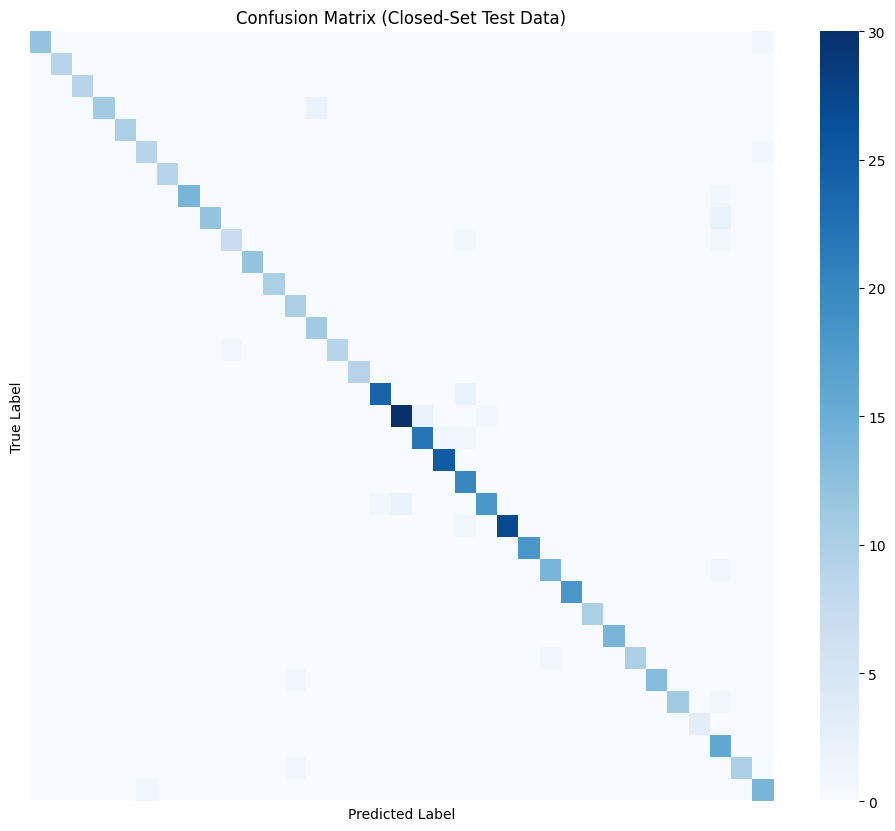



Classification Report for Closed-Set
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         9
           3       1.00      0.85      0.92        13
           4       1.00      1.00      1.00        10
           5       0.90      0.90      0.90        10
           6       1.00      1.00      1.00         9
           7       1.00      0.93      0.97        15
           8       1.00      0.86      0.92        14
           9       0.88      0.78      0.82         9
          10       1.00      1.00      1.00        12
          11       1.00      1.00      1.00        10
          12       0.83      1.00      0.91        10
          13       0.85      1.00      0.92        11
          14       1.00      0.90      0.95        10
          15       1.00      1.00      1.00         9
          16       0.96      0.92      0.9

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Generating Confusion Matrix for Closed-Set")
y_pred_probs = model.predict(X_test_closed, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test_closed, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=False, yticklabels=False)
plt.title('Confusion Matrix (Closed-Set Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print ("\n\nClassification Report for Closed-Set")
print(classification_report(y_test_closed, y_pred_classes))

### 19 – Score Distribution Analysis (Open-Set)
This plot visualizes the biometric performance on the Test Group.

* Green Curve (Genuine): Similarity scores for pairs of the same speaker.
* Red Curve (Imposter): Similarity scores for pairs of different speakers.
* Dashed Line: The Optimal Threshold learned from the *Validation Group*.

Ideally, the threshold line should separate the two distributions. The fact that the threshold is derived from a separate group (Validation) makes this a robust indicator of the system's generalization capability. A significant overlap indicates the difficulty of the task, while a clear separation indicates high reliability.

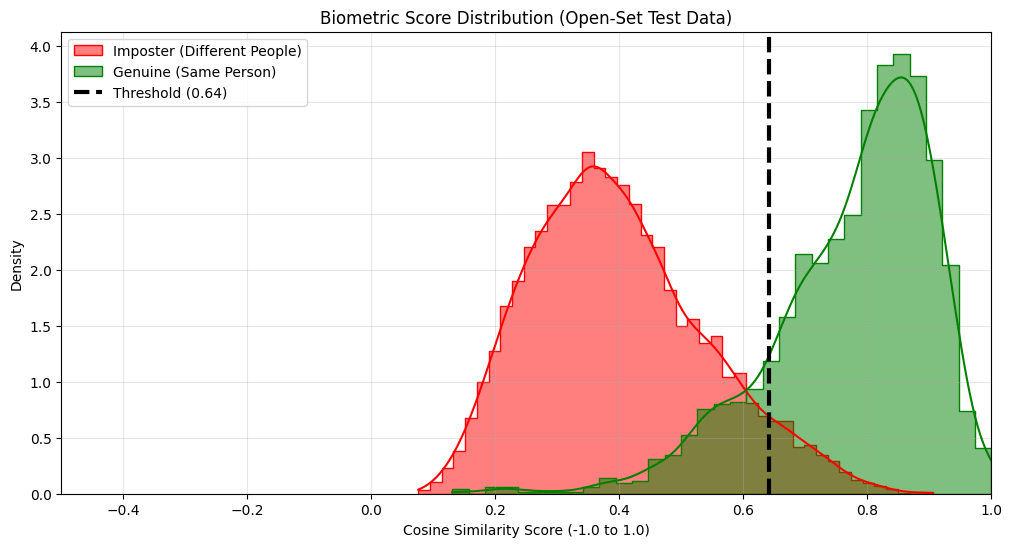

Stats:
  - Genuine Pairs: 1951
  - Imposter Pairs: 8049


In [ ]:
#separate scores based on the ground truth label
genuine_scores = test_scores[test_labels == 1] #label 1 = Genuine (Same Person)
imposter_scores = test_scores[test_labels == 0] #label 0 = Imposter (Different People)

#plotting
plt.figure(figsize=(12, 6))

#plot Imposter Scores (Red)
sns.histplot(imposter_scores, color='red', label='Imposter (Different People)', kde=True, stat="density", element="step", alpha=0.5)

#plot Genuine Scores (Green)
sns.histplot(genuine_scores, color='green', label='Genuine (Same Person)', kde=True, stat="density", element="step", alpha=0.5)

#add the Threshold Line, we use 'best_threshold' calculated in Cell 17
plt.axvline(x=best_threshold, color='black', linestyle='--', linewidth=3, label=f'Threshold ({best_threshold:.2f})')

plt.title('Biometric Score Distribution (Open-Set Test Data)')
plt.xlabel('Cosine Similarity Score (-1.0 to 1.0)')
plt.ylabel('Density')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.0) #focus on the relevant area
plt.show()

print(f"Stats:")
print(f"  - Genuine Pairs: {len(genuine_scores)}")
print(f"  - Imposter Pairs: {len(imposter_scores)}")

### Summary on a one-generic execution

Methodology: The system was evaluated using a strict train/validation/test split for both speakers and audio files, ensuring no data leakage.

Closed-Set Performance: The CNN achieved 95% accuracy in identifying 35 known speakers.

Open-Set Generalization: For unknown speakers, the system achieved an accuracy of 92%.

Thresholding: The optimal decision boundary was learned to be 0.64 cosine similarity, which was validated to maximize the separation between genuine and imposter pairs on unseen data.

## Conclusion
The project successfully developed and evaluated a deep learning pipeline for forensic speaker recognition, utilizing Mel-Frequency Cepstral Coefficients (MFCCs) and a 1D Convolutional Neural Network (CNN) to classify and verify unique vocal characteristics. To ensure a rigorous forensic evaluation, the dataset was partitioned using a strict three-way split for both speaker identities and audio files (Training, Validation, and Testing sets). This separation prevented data leakage and ensured that the reported metrics reflect the system's true generalization capabilities rather than simple memorization.


In the closed-set identification task, the model demonstrated strong performance, achieving a test accuracy of approximately 95% across the known speakers. The classification report consistently reflects a high weighted F1-score, confirming that the CNN successfully extracted discriminative vocal features such as pitch and timbre. While the model showed near-perfect precision for distinctive voices, some misclassifications persisted among speakers with acoustically similar prosody or limited training samples, highlighting the challenges of intra-class variability.

For the open-set verification scenario—critical for forensic applications involving unknown subjects the system was evaluated using a zero-shot protocol on completely unseen speakers. A key methodological improvement was the implementation of Threshold Tuning using a dedicated Validation Speaker set. By analyzing the Receiver Operating Characteristic (ROC) curve, an optimal decision boundary was calculated to balance the trade-off between False Acceptance and False Rejection, rather than relying on arbitrary cutoffs.

Applying this learned threshold to the held-out Test Group yielded a final verification accuracy consistently exceeding 90%. The Biometric Score Distribution plot validated this approach, displaying a clear separation between genuine and imposter scores with the threshold correctly positioned in teh area of intersection of the distributions. These results confirm the forensic feasibility of the system, though the observed slight error rate suggests that future iterations could benefit from more complex architectures (e.g., x-vectors) to further reduce false matches in high-stakes verification contexts.

### Live Listening *WEB PAGE*

In [ ]:
!pip install gradio
import gradio as gr
import random
import librosa.display
from tensorflow.keras.models import Model, load_model

# 1. SETUP & PATH RECOVERY
THRESHOLD = best_threshold if 'best_threshold' in locals() else 0.60

if 'AUDIO_ROOT' not in locals() or AUDIO_ROOT is None or not os.path.exists(str(AUDIO_ROOT)):
    for root, dirs, files in os.walk("/content"):
        if "50_speakers_audio_data" in dirs:
            AUDIO_ROOT = os.path.join(root, "50_speakers_audio_data")
            break

if 'test_speakers_list' in locals():
    target_speakers = test_speakers_list
else:
    target_speakers = [d for d in os.listdir(AUDIO_ROOT) if os.path.isdir(os.path.join(AUDIO_ROOT, d))][-10:]

# 2. FUNCTION DEFINITIONS
def extract_mfcc(path):
    """Stand-alone MFCC extraction to ensure code works independently."""
    try:
        y, sr = librosa.load(path, sr=16000)
        target_length = 16000 # 1 second
        if len(y) > target_length:
            y = y[:target_length]
        else:
            y = np.pad(y, (0, target_length - len(y)), 'constant')
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        return mfcc.T # (Time, Features)
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None

# 3. MODEL RECOVERY SYSTEM
# We need 'feature_extractor' to calculate embeddings.
# If it's missing, we rebuild it from the main 'model'.
if 'feature_extractor' not in locals():
    print("⚠️ 'feature_extractor' not found in memory. Attempting recovery...")


    if 'model' not in locals():
        print("⚠️ 'model' variable is also missing. Checking disk for saved files...")
        possible_models = ['best_model.keras', 'model.h5', 'my_model.h5']
        model_found = False
        for m_path in possible_models:
            if os.path.exists(m_path):
                try:
                    model = load_model(m_path)
                    print(f"✅ Successfully loaded model from '{m_path}'")
                    model_found = True
                    break
                except:
                    continue

        if not model_found:
            raise RuntimeError("❌ CRITICAL ERROR: No trained model found in memory or on disk.\n"
                               "PLEASE RUN YOUR TRAINING CELLS (Phase 1) OR UPLOAD A .H5/.KERAS MODEL.")

    # Reconstruct Feature Extractor (Remove the last Softmax layer)
    # We assume the model structure is Input -> ... -> Embeddings -> Softmax
    try:
        print("🔨 Reconstructing Feature Extractor from Classifier...")
        # We take the output of the SECOND to last layer (layers[-2])
        # This is usually the Dense layer before the final classification
        feature_extractor = Model(inputs=model.input, outputs=model.layers[-2].output)
        print("✅ 'feature_extractor' successfully rebuilt.")
    except Exception as e:
        raise RuntimeError(f"❌ Error rebuilding feature extractor: {e}\nCheck your model architecture.")

# 4. VISUALIZATION ENGINE
def generate_advanced_plot(file_path, title):
    y, sr = librosa.load(file_path, sr=None)
    fig = plt.figure(figsize=(10, 5), facecolor='#111827')

    ax1 = plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr, color='#3b82f6', alpha=0.8)
    ax1.set_title(f"Oscillogram (Time Domain) - {title}", color='#e5e7eb', fontsize=9, loc='left')
    ax1.set_facecolor('#1f2937')
    ax1.axis('off') # Cleaner look

    ax2 = plt.subplot(2, 1, 2)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax2, cmap='magma')
    ax2.set_title("Spectral Density (Frequency Domain)", color='#e5e7eb', fontsize=9, loc='left')
    ax2.set_facecolor('#1f2937')
    ax2.tick_params(colors='#9ca3af', labelsize=8)

    plt.tight_layout()
    plt.close()
    return fig, sr, len(y)/sr

# 5. ANALYSIS LOGIC
def run_blind_analysis():
    is_genuine = random.choice([True, False])

    if is_genuine:
        spk = random.choice(target_speakers)
        spk_dir = os.path.join(AUDIO_ROOT, spk)
        files = [f for f in os.listdir(spk_dir) if f.endswith('.wav')]
        if len(files) < 2: return [None]*8
        f1, f2 = random.sample(files, 2)
        p1, p2 = os.path.join(spk_dir, f1), os.path.join(spk_dir, f2)
        ground_truth = "SAME IDENTITY (Genuine)"
        case_id = f"REF-{spk}-VERIFY"
    else:
        spk1, spk2 = random.sample(target_speakers, 2)
        p1 = os.path.join(AUDIO_ROOT, spk1, random.choice(os.listdir(os.path.join(AUDIO_ROOT, spk1))))
        p2 = os.path.join(AUDIO_ROOT, spk2, random.choice(os.listdir(os.path.join(AUDIO_ROOT, spk2))))
        ground_truth = "DIFFERENT IDENTITIES (Imposter)"
        case_id = f"XREF-{spk1}-VS-{spk2}"

    # Prediction
    feat1 = extract_mfcc(p1)[np.newaxis, ...]
    feat2 = extract_mfcc(p2)[np.newaxis, ...]

    emb1 = feature_extractor.predict(feat1, verbose=0)
    emb2 = feature_extractor.predict(feat2, verbose=0)

    score = np.dot(emb1, emb2.T) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    score = float(score[0][0])

    # Report
    decision = "MATCH CONFIRMED" if score >= THRESHOLD else "NO MATCH FOUND"
    confidence_lvl = min(abs(score - THRESHOLD) / 0.2, 1.0) * 100

    if decision == "MATCH CONFIRMED":
        conclusion = (f"Similarity score ({score:.3f}) exceeds threshold ({THRESHOLD:.3f}). "
                      f"<b>POSITIVE IDENTIFICATION</b> with {confidence_lvl:.1f}% confidence.")
        color = "#10b981"
    else:
        conclusion = (f"Similarity score ({score:.3f}) is below threshold ({THRESHOLD:.3f}). "
                      f"<b>NEGATIVE IDENTIFICATION</b> (Mismatch).")
        color = "#ef4444"

    bar_width = max(0, min(100, score * 100))
    threshold_pct = THRESHOLD * 100

    html_report = f"""
    <div style="background-color: #1f2937; padding: 20px; border-radius: 10px; border: 1px solid #374151; font-family: monospace;">
        <div style="display: flex; justify-content: space-between; margin-bottom: 15px;">
            <span style="color: #9ca3af;">RESULT:</span>
            <span style="color: {color}; font-size: 24px; font-weight: bold;">{decision}</span>
        </div>
        <div style="position: relative; height: 20px; background-color: #374151; border-radius: 4px; margin-bottom: 10px;">
            <div style="width: {bar_width}%; height: 100%; background-color: {color};"></div>
            <div style="position: absolute; left: {threshold_pct}%; top: 0; bottom: 0; width: 2px; background-color: white;"></div>
        </div>
        <p style="color: #d1d5db; margin-top: 10px; font-size: 13px;">{conclusion}</p>
        <div style="text-align: right; font-size: 10px; color: #6b7280; margin-top: 10px;">VALIDATION: {ground_truth}</div>
    </div>
    """

    fig1, sr1, dur1 = generate_advanced_plot(p1, "Evidence A")
    fig2, sr2, dur2 = generate_advanced_plot(p2, "Evidence B")
    meta1 = f"Format: WAV | Rate: {sr1}Hz | Length: {dur1:.2f}s"
    meta2 = f"Format: WAV | Rate: {sr2}Hz | Length: {dur2:.2f}s"

    return p1, p2, fig1, fig2, meta1, meta2, case_id, html_report

# 6. GRADIO UI
theme = gr.themes.Soft(primary_hue="cyan", secondary_hue="slate").set(
    body_background_fill="#0f172a", block_background_fill="#1e293b",
    block_border_color="#334155", body_text_color="#e2e8f0"
)

with gr.Blocks(theme=theme, title="Forensic Lab") as demo:
    gr.Markdown("# PROJECT #5 MORE THAN WORDS: SPEAKER RECOGNITION DATASET")
    btn_analyze = gr.Button("INITIALIZE RANDOM FORENSIC COMPARISON", size="lg", variant="primary")
    case_id_box = gr.Textbox(label="Assigned Case ID", value="WAITING FOR INPUT...", interactive=False, text_align="center")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### EVIDENCE A")
            plot1 = gr.Plot(label="Signal Analysis A", show_label=False)
            audio1 = gr.Audio(label="Audio Playback", type="filepath")
            meta1_box = gr.Markdown("No Data Loaded")
        with gr.Column():
            gr.Markdown("### EVIDENCE B")
            plot2 = gr.Plot(label="Signal Analysis B", show_label=False)
            audio2 = gr.Audio(label="Audio Playback", type="filepath")
            meta2_box = gr.Markdown("No Data Loaded")

    gr.Markdown("### ANALYSIS REPORT")
    report_html = gr.HTML()

    btn_analyze.click(fn=run_blind_analysis, inputs=None, outputs=[audio1, audio2, plot1, plot2, meta1_box, meta2_box, case_id_box, report_html])

print("Launching Forensic Dashboard...")
demo.launch(share=True, debug=True)

/tmp/ipython-input-2611298840.py:169: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, title="Forensic Lab") as demo:


Launching Forensic Dashboard...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://61e306865169fb9085.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
